# Study Hours → Exam Score

## Prediction problem
Estimate a student's exam score from the number of hours studied.

## Input
One numerical value: study hours.

## Target
One numerical value: exam score.
We will verify the units and score scale when selecting the dataset.

## Historical examples
Recorded study-hours and exam-score pairs.
We will document their source and any uncertainty about their origin.

## Intended use
An educational demonstration of learning a relationship from data
and measuring prediction errors.

## Limitation
A relationship in the data does not prove that additional study hours
cause a particular score increase.

In [3]:
print("Input: study hours")
print("Target: exam score")

Input: study hours
Target: exam score


## Load and inspect the dataset

Read the CSV into a Pandas table.
Check its contents and structure before selecting columns or training.

### Loading instructions

Upload study_hours_scores_regression.csv into the Colab Files panel
before running the loading cell. Repeat this in a fresh runtime.
The notebook reads the file using a relative path.

In [9]:
import pandas as pd

data = pd.read_csv("study_hours_scores_regression.csv")

In [5]:
data.head(3)

,Hours,Scores
0,8.87,36.80
1,4.45,51.88
2,7.08,85.64


In [6]:
print(data.shape)

(100, 2)


In [7]:
print(data.columns)

Index(['Hours', 'Scores'], dtype='object')


In [8]:
print(data.dtypes)

Hours     float64
Scores    float64
dtype: object


## Data validation

Check missing values, numeric interpretation, duplicate rows,
and documented ranges before training.

Document any correction and its reason before applying it.

In [12]:
print(data.isna().sum())

Hours     0
Scores    0
dtype: int64


In [13]:
hours_check = pd.to_numeric(data["Hours"], errors="coerce")
scores_check = pd.to_numeric(data["Scores"], errors="coerce")

In [14]:
bad_hours = data["Hours"].notna() & hours_check.isna()
bad_scores = data["Scores"].notna() & scores_check.isna()

print("Nonnumeric hours:", bad_hours.sum())
print("Nonnumeric scores:", bad_scores.sum())

Nonnumeric hours: 0
Nonnumeric scores: 0


In [15]:
print("Repeated rows after the first occurrence:", data.duplicated().sum())

Repeated rows after the first occurrence: 0


In [16]:
data[data.duplicated(keep=False)]

,Hours,Scores


In [17]:
outside_hours = (hours_check < 0) | (hours_check > 10)
outside_scores = (scores_check < 0) | (scores_check > 100)

print("Hours outside 0–10:", outside_hours.sum())
print("Scores outside 0–100:", outside_scores.sum())

Hours outside 0–10: 0
Scores outside 0–100: 0


### Validation findings

- Missing Hours values: 0
- Missing Scores values: 0
- Nonnumeric Hours values: 0
- Nonnumeric Scores values: 0
- Repeated rows after the first occurrence: 0
- Hours outside the documented range: 0
- Scores outside the documented range: 0

### Decision

These checks detected no issues. The data remains unchanged. This does not establish real-world representativeness.

## Visualize study hours and scores

Each dot represents one synthetic example.
Inspect the direction, spread, and unusual points.
A visible relationship would not establish causation.

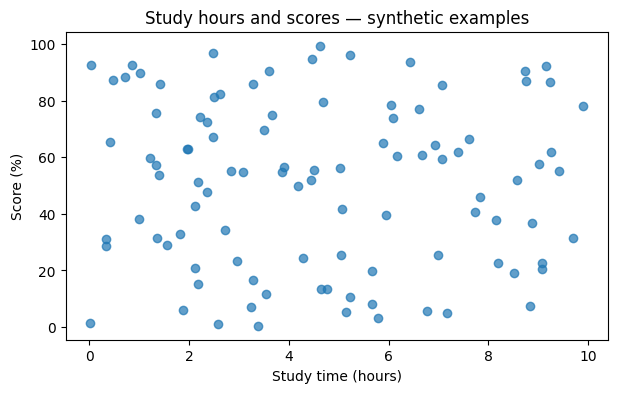

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.scatter(data["Hours"], data["Scores"], alpha=0.7)
plt.xlabel("Study time (hours)")
plt.ylabel("Score (%)")
plt.title("Study hours and scores — synthetic examples")
plt.show()

In [20]:
print("Observed hours:", data["Hours"].min(), "to", data["Hours"].max())
print("Observed scores:", data["Scores"].min(), "to", data["Scores"].max())

Observed hours: 0.02 to 9.91
Observed scores: 0.46 to 99.42


### Plot observations

- Direction: There is no clear visual relationship between hours and scores.
- Spread of scores at similar study hours:
- Observed hours range: 0.02 to 9.91
- Observed score range: 0.46 to 99.42
- Unusual points or gaps: None

These observations describe this synthetic dataset.
They do not establish that additional study causes higher scores.
Model performance has not yet been measured.